In [1]:
import pandas as pd
import numpy as np
import anndata
import json
import os
import scanpy as sc
from sklearn.model_selection import train_test_split

## Data inspection

In [2]:
# 1. Read the data
adata = anndata.read_h5ad("../data_centralized/pancreas_train.h5ad")

In [3]:
# 2. Display the AnnData object summary
print("AnnData object summary:")
print(adata)

AnnData object summary:
AnnData object with n_obs × n_vars = 9362 × 19093
    obs: 'tech', 'celltype', 'size_factors'
    layers: 'counts'


In [4]:
# 3. Display the first few rows of the observation metadata
print("\nFirst 5 rows of adata.obs:")
print(adata.obs.head())


First 5 rows of adata.obs:
                                   tech celltype  size_factors
3rd-C86_S85                  fluidigmc1    delta      5.060723
human3_lib4.final_cell_0804     inDrop3    alpha      0.010361
human3_lib4.final_cell_0815     inDrop3     beta      0.011553
Sample_163                      smarter     beta      1.000000
human3_lib1.final_cell_0737     inDrop3    alpha      0.014493


In [5]:
# 4. Display available layers
print("\nAvailable layers in adata:")
print(adata.layers.keys())


Available layers in adata:
KeysView(Layers with keys: counts)


In [6]:
# 5. Display the first 5x5 block of the counts layer (if it exists)
print("\nFirst 5x5 of counts layer:")
print(pd.DataFrame(adata.layers["counts"][:5, :5], 
                    columns=adata.var_names[:5], 
                    index=adata.obs_names[:5]))


First 5x5 of counts layer:
                             A1BG  A1CF  A2M  A2ML1  A4GALT
3rd-C86_S85                  14.7  11.0  0.0    3.0     0.0
human3_lib4.final_cell_0804   0.0   0.0  0.0    0.0     0.0
human3_lib4.final_cell_0815   0.0   0.0  0.0    0.0     0.0
Sample_163                    0.0   0.0  0.0    0.0     0.0
human3_lib1.final_cell_0737   0.0   1.0  0.0    0.0     0.0


In [7]:
# 6. How many unique technologies are present, and what are their names?

techs = adata.obs['tech'].unique()
print(f"Number of unique technologies: {len(techs)}")
print("Technologies:", ", ".join(techs))

Number of unique technologies: 7
Technologies: fluidigmc1, inDrop3, smarter, inDrop1, celseq, inDrop4, inDrop2


In [8]:
# 7. What is the total number of genes measured in the dataset?

num_genes = adata.shape[1]
print(f"\nTotal number of genes measured: {num_genes}")


Total number of genes measured: 19093


In [9]:
# 8. What is the total number of samples (cells) in the dataset?

num_samples = adata.shape[0]
print(f"\nTotal number of samples (cells): {num_samples}")


Total number of samples (cells): 9362


In [10]:
# 9. How many samples (cells) belong to each technology?

tech_counts = adata.obs['tech'].value_counts()
print("\nNumber of samples (cells) per technology:")
print(tech_counts.to_string())


Number of samples (cells) per technology:
tech
inDrop3       2884
inDrop1       1550
inDrop2       1379
smarter       1194
inDrop4       1042
celseq         803
fluidigmc1     510


## Variance analysis

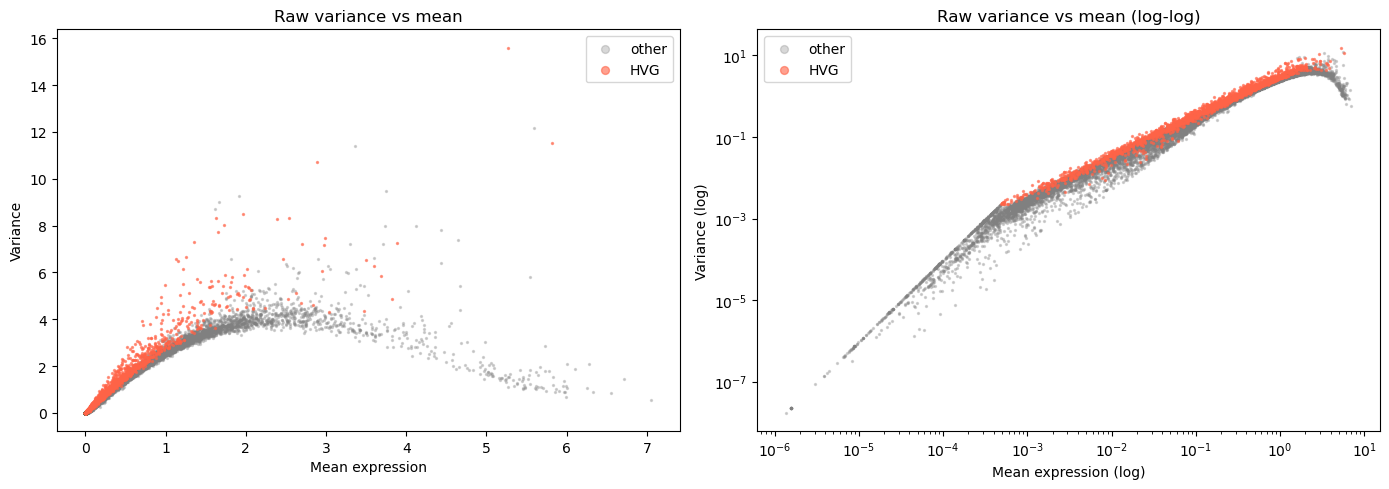

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import scanpy as sc

# Compute per-gene mean and variance from raw counts
mean_expr = np.array(adata.X.mean(axis=0)).flatten()
# For sparse matrices:
var_expr   = np.array(adata.X.var(axis=0)).flatten()

# Run HVG to get the normalized dispersion scores
sc.pp.highly_variable_genes(adata, n_top_genes=2000, flavor='seurat', inplace=True)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: raw variance vs mean ---
ax = axes[0]
hvg_mask = adata.var['highly_variable']
ax.scatter(mean_expr[~hvg_mask], var_expr[~hvg_mask], s=2, alpha=0.3, color='grey', label='other')
ax.scatter(mean_expr[hvg_mask],  var_expr[hvg_mask],  s=2, alpha=0.6, color='tomato', label='HVG')
ax.set_xlabel('Mean expression')
ax.set_ylabel('Variance')
ax.set_title('Raw variance vs mean')
ax.legend(markerscale=4)

# --- Right: same but log-log scale to see the trend clearly ---
ax = axes[1]
ax.scatter(mean_expr[~hvg_mask], var_expr[~hvg_mask], s=2, alpha=0.3, color='grey', label='other')
ax.scatter(mean_expr[hvg_mask],  var_expr[hvg_mask],  s=2, alpha=0.6, color='tomato', label='HVG')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Mean expression (log)')
ax.set_ylabel('Variance (log)')
ax.set_title('Raw variance vs mean (log-log)')
ax.legend(markerscale=4)

plt.tight_layout()
plt.show()

## HVG identification

### Built-in function

In [12]:
from app.task import compute_hvg_client_stats, compute_hvg_from_stats

import json
from typing import List, Dict

# Load the all genes list
with open("../data_centralized/all_genes.json", "r") as f:
    all_genes_list = json.load(f)


In [13]:
# Built-in on full adata (without batch_key to match custom, which doesn't account for batches)
builtin_df = sc.pp.highly_variable_genes(adata, n_top_genes=2000, subset=False, inplace=False)
builtin_df.head()

,means,dispersions,mean_bin,dispersions_norm,highly_variable
A1BG,0.888298,3.555723,"(0.498, 0.996]",-1.164785,False
A1CF,2.299937,4.117117,"(1.992, 2.49]",-0.259007,False
A2M,0.898153,4.448194,"(0.498, 0.996]",0.725122,False
A2ML1,0.049403,2.610367,"(-0.00996, 0.498]",-0.442184,False
A4GALT,1.002188,4.134097,"(0.996, 1.494]",0.047165,False


### With custom functions (two-step process)

In [ ]:
stats = compute_hvg_client_stats(adata, all_genes_list)
print(stats.keys()) 
print("Sum head:", stats['sum'][:5])
print("Sum_sq head:", stats['sum_sq'][:5])
print("Gene names head:", stats['gene_names'][:5]) 
print("n_cells:", stats['n_cells'])

ours_df =compute_hvg_from_stats(stats['sum'], stats['sum_sq'], stats['n_cells'], stats['gene_names'])
ours_df.head()

dict_keys(['sum', 'sum_sq', 'gene_names', 'n_cells'])
Sum head: [13396.906   84010.35    13622.31      474.12912 16142.296  ]
Sum_sq head: [4.8818822e+05 5.9100455e+06 1.1840288e+06 6.4733940e+03 1.0355409e+06]
Gene names head: ['A1BG', 'A1CF', 'A2M', 'A2ML1', 'A4GALT']
n_cells: 9362.0


,means,dispersions,mean_bin,dispersions_norm,highly_variable
A1BG,0.888298,3.555723,"(0.498, 0.996]",-1.164784,False
A1CF,2.299936,4.117117,"(1.992, 2.49]",-0.259006,False
A2M,0.898153,4.448194,"(0.498, 0.996]",0.725122,False
A2ML1,0.049403,2.610367,"(-0.00996, 0.498]",-0.442184,False
A4GALT,1.002188,4.134097,"(0.996, 1.494]",0.047166,False


### Additivity of the process based on custom functions

In [17]:
# Splitting into two adatas
n_cells = adata.n_obs
idx = np.random.permutation(n_cells)
split = n_cells // 2

adata_1 = adata[idx[:split]].copy()
adata_2 = adata[idx[split:]].copy()

In [22]:
# Stats for both 
stats_1 = compute_hvg_client_stats(adata_1, all_genes_list)
stats_2 = compute_hvg_client_stats(adata_2, all_genes_list)

# Retrieving global HVGs
ours_additive_df =compute_hvg_from_stats(
    stats_1['sum']+stats_2['sum'], 
    stats_1['sum_sq']+stats_2['sum_sq'], 
    stats_1['n_cells']+stats_2['n_cells'], 
    stats_1['gene_names'] # any of the two will work here
    )
ours_additive_df.head()

,means,dispersions,mean_bin,dispersions_norm,highly_variable
A1BG,0.888298,3.555723,"(0.498, 0.996]",-1.164784,False
A1CF,2.299937,4.117116,"(1.992, 2.49]",-0.259009,False
A2M,0.898153,4.448194,"(0.498, 0.996]",0.725122,False
A2ML1,0.049403,2.610367,"(-0.00996, 0.498]",-0.442184,False
A4GALT,1.002188,4.134097,"(0.996, 1.494]",0.047165,False


### Final save

In [15]:
# Save the top 2000 genes from built-in
top2000_genes = builtin_df[builtin_df['highly_variable']].index.tolist()
with open("../data_centralized/top2k_genes.json", "w") as f:
    json.dump(top2000_genes, f, indent=2)
print(f"Saved {len(top2000_genes)} top genes to ../data_centralized/top2k_genes.json")


Saved 2000 top genes to ../data_centralized/top2k_genes.json
